# DAMR by Model and Error Category

In [2]:
%matplotlib inline

from pathlib import Path
import textwrap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ALL_MODEL_ORDER = ["base", "sft", "dpo_01", "dpo_03", "dpo_05"]
MODEL_ORDER = ["base", "sft", "dpo_01", "dpo_03", "dpo_05"]
DIMS = [
    "mistake_identification", "mistake_location", "revealing_answer",
    "providing_guidance", "actionability", "coherence", "tutor_tone", "human_likeness",
]
DESIRED = {dim: "Yes" for dim in DIMS}
DESIRED.update(revealing_answer="No", tutor_tone="Encouraging")
FILES = {model: f"pedagogy_eval_{model}.csv" for model in ALL_MODEL_ORDER}
CANDIDATES = [
    Path.cwd() / "pedagogy_evaluation",
    Path.cwd() / "2__SFT_DPO__" / "pedagogy_evaluation",
]
EVAL_DIR = next(
    (folder for folder in CANDIDATES if all((folder / name).is_file() for name in FILES.values())),
    None,
)
if EVAL_DIR is None:
    raise FileNotFoundError(f"Required per-model CSVs not found in: {CANDIDATES}")

LABEL_COLUMNS = [f"{dim}_label" for dim in DIMS]
REQUIRED_COLUMNS = ["idx", "llm_name", "error_category", *LABEL_COLUMNS]
dfs = {}
for model, name in FILES.items():
    df = pd.read_csv(EVAL_DIR / name)
    missing = set(REQUIRED_COLUMNS) - set(df.columns)
    if missing:
        raise ValueError(f"{model}: missing columns {sorted(missing)}")
    if df.empty or df[REQUIRED_COLUMNS].isna().any().any():
        raise ValueError(f"{model}: empty data or missing required values")
    if not df["idx"].is_unique:
        raise ValueError(f"{model}: duplicate idx")
    if not df["llm_name"].eq(model).all():
        raise ValueError(f"{model}: llm_name mismatch")
    if not df["error_category"].map(lambda value: isinstance(value, str) and bool(value.strip())).all():
        raise ValueError(f"{model}: invalid error_category")
    if not df[LABEL_COLUMNS].map(lambda value: isinstance(value, str) and bool(value.strip())).all().all():
        raise ValueError(f"{model}: invalid labels")
    dfs[model] = df.set_index("idx").sort_index()

reference = dfs["sft"]
for model, df in dfs.items():
    if not df.index.equals(reference.index):
        raise ValueError(f"{model}: idx not aligned with sft")
    if not df["error_category"].equals(reference["error_category"]):
        raise ValueError(f"{model}: error_category not aligned with sft by idx")
CAT_ORDER = reference["error_category"].drop_duplicates().tolist()
if len(CAT_ORDER) != 7:
    raise ValueError(f"Expected 7 error_category values, found {len(CAT_ORDER)}")
category_n = reference["error_category"].value_counts().reindex(CAT_ORDER)

# Each rate uses exact desired-label matches; no precomputed scores or aggregates.
model_damr = pd.DataFrame(
    {
        model: [dfs[model][f"{dim}_label"].eq(DESIRED[dim]).mean() * 100 for dim in DIMS]
        for model in ALL_MODEL_ORDER
    },
    index=DIMS,
)
model_desired_count = pd.DataFrame(
    {
        model: [int(dfs[model][f"{dim}_label"].eq(DESIRED[dim]).sum()) for dim in DIMS]
        for model in ALL_MODEL_ORDER
    },
    index=DIMS,
)
damr_by_dimension = {
    dim: pd.DataFrame({
        model: dfs[model][f"{dim}_label"].eq(DESIRED[dim]).groupby(dfs[model]["error_category"]).mean().mul(100)
        for model in MODEL_ORDER
    }).reindex(index=CAT_ORDER, columns=MODEL_ORDER)
    for dim in DIMS
}
print(f"n={len(reference)} × {len(ALL_MODEL_ORDER)} models; unique/aligned idx and error_category verified")
print(f"CSV directory: {EVAL_DIR}")

n=298 × 5 models; unique/aligned idx and error_category verified
CSV directory: /Users/jay/Desktop/___TUM_Thesis /____Final_Thesis_Repository/2__SFT_DPO__/pedagogy_evaluation


## DAMR per models

,base,sft,dpo_01,dpo_03,dpo_05
mistake_identification,95.30% (284/298),41.61% (124/298),63.09% (188/298),65.10% (194/298),83.89% (250/298)
mistake_location,93.29% (278/298),38.93% (116/298),50.67% (151/298),51.34% (153/298),68.79% (205/298)
revealing_answer,98.66% (294/298),93.96% (280/298),70.13% (209/298),88.59% (264/298),80.87% (241/298)
providing_guidance,88.59% (264/298),28.19% (84/298),14.43% (43/298),22.82% (68/298),27.18% (81/298)
actionability,88.59% (264/298),29.87% (89/298),14.43% (43/298),27.18% (81/298),28.86% (86/298)
coherence,99.66% (297/298),97.65% (291/298),90.94% (271/298),95.30% (284/298),96.31% (287/298)
tutor_tone,100.00% (298/298),69.80% (208/298),24.83% (74/298),49.66% (148/298),34.90% (104/298)
human_likeness,99.66% (297/298),84.56% (252/298),48.32% (144/298),72.82% (217/298),62.42% (186/298)


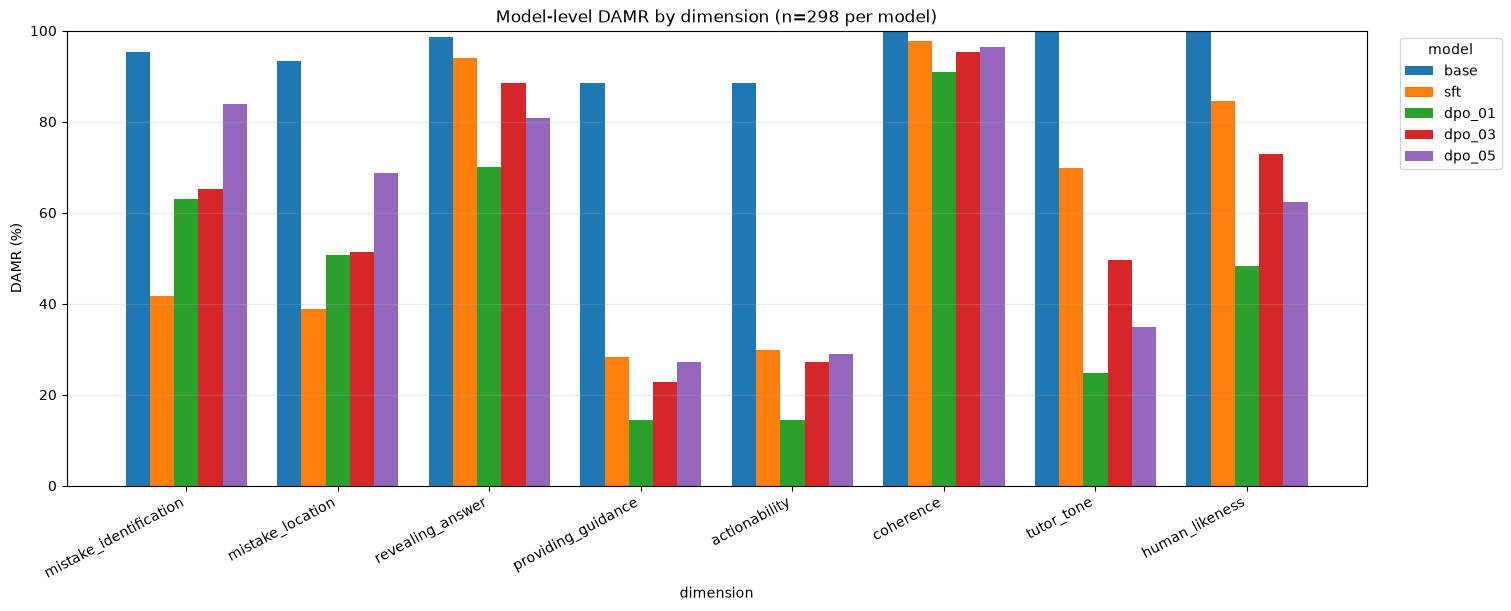

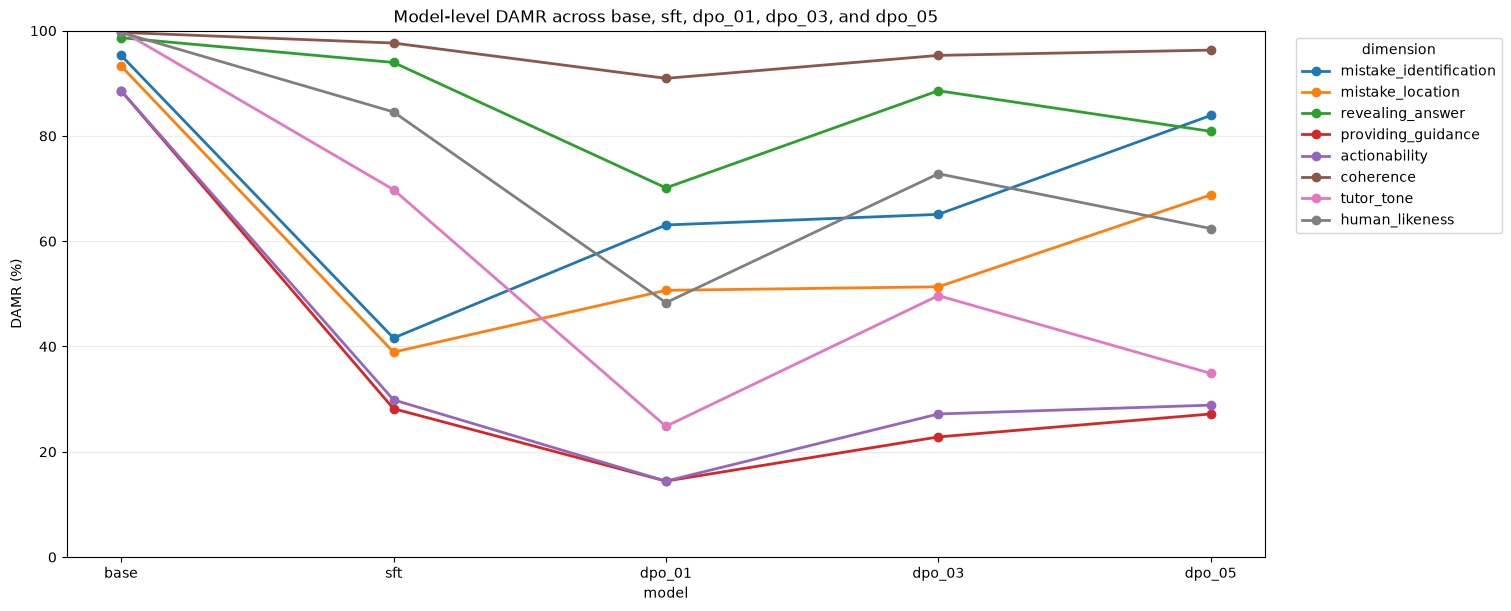

In [3]:
model_damr_display = pd.DataFrame(index=DIMS)
for model in ALL_MODEL_ORDER:
    model_damr_display[model] = [
        f"{model_damr.loc[dim, model]:.2f}% ({model_desired_count.loc[dim, model]}/{len(reference)})"
        for dim in DIMS
    ]
display(model_damr_display)

fig, ax = plt.subplots(figsize=(15, 6), layout="constrained")
x = np.arange(len(DIMS))
width = 0.16

for model_index, model in enumerate(ALL_MODEL_ORDER):
    offset = (model_index - (len(ALL_MODEL_ORDER) - 1) / 2) * width
    ax.bar(x + offset, model_damr[model].to_numpy(), width, label=model)

ax.set_xticks(x, DIMS, rotation=28, ha="right")
ax.set_ylim(0, 100)
ax.set_ylabel("DAMR (%)")
ax.set_xlabel("dimension")
ax.set_title("Model-level DAMR by dimension (n=298 per model)")
ax.legend(title="model", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.grid(axis="y", alpha=0.25)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(15, 6), layout="constrained")
for dim in DIMS:
    ax.plot(
        ALL_MODEL_ORDER,
        model_damr.loc[dim, ALL_MODEL_ORDER],
        marker="o",
        linewidth=2,
        label=dim,
    )

ax.set_ylim(0, 100)
ax.set_ylabel("DAMR (%)")
ax.set_xlabel("model")
ax.set_title("Model-level DAMR across base, sft, dpo_01, dpo_03, and dpo_05")
ax.legend(title="dimension", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.grid(axis="y", alpha=0.25)
plt.show()
plt.close(fig)

## error_category DAMR per dimension

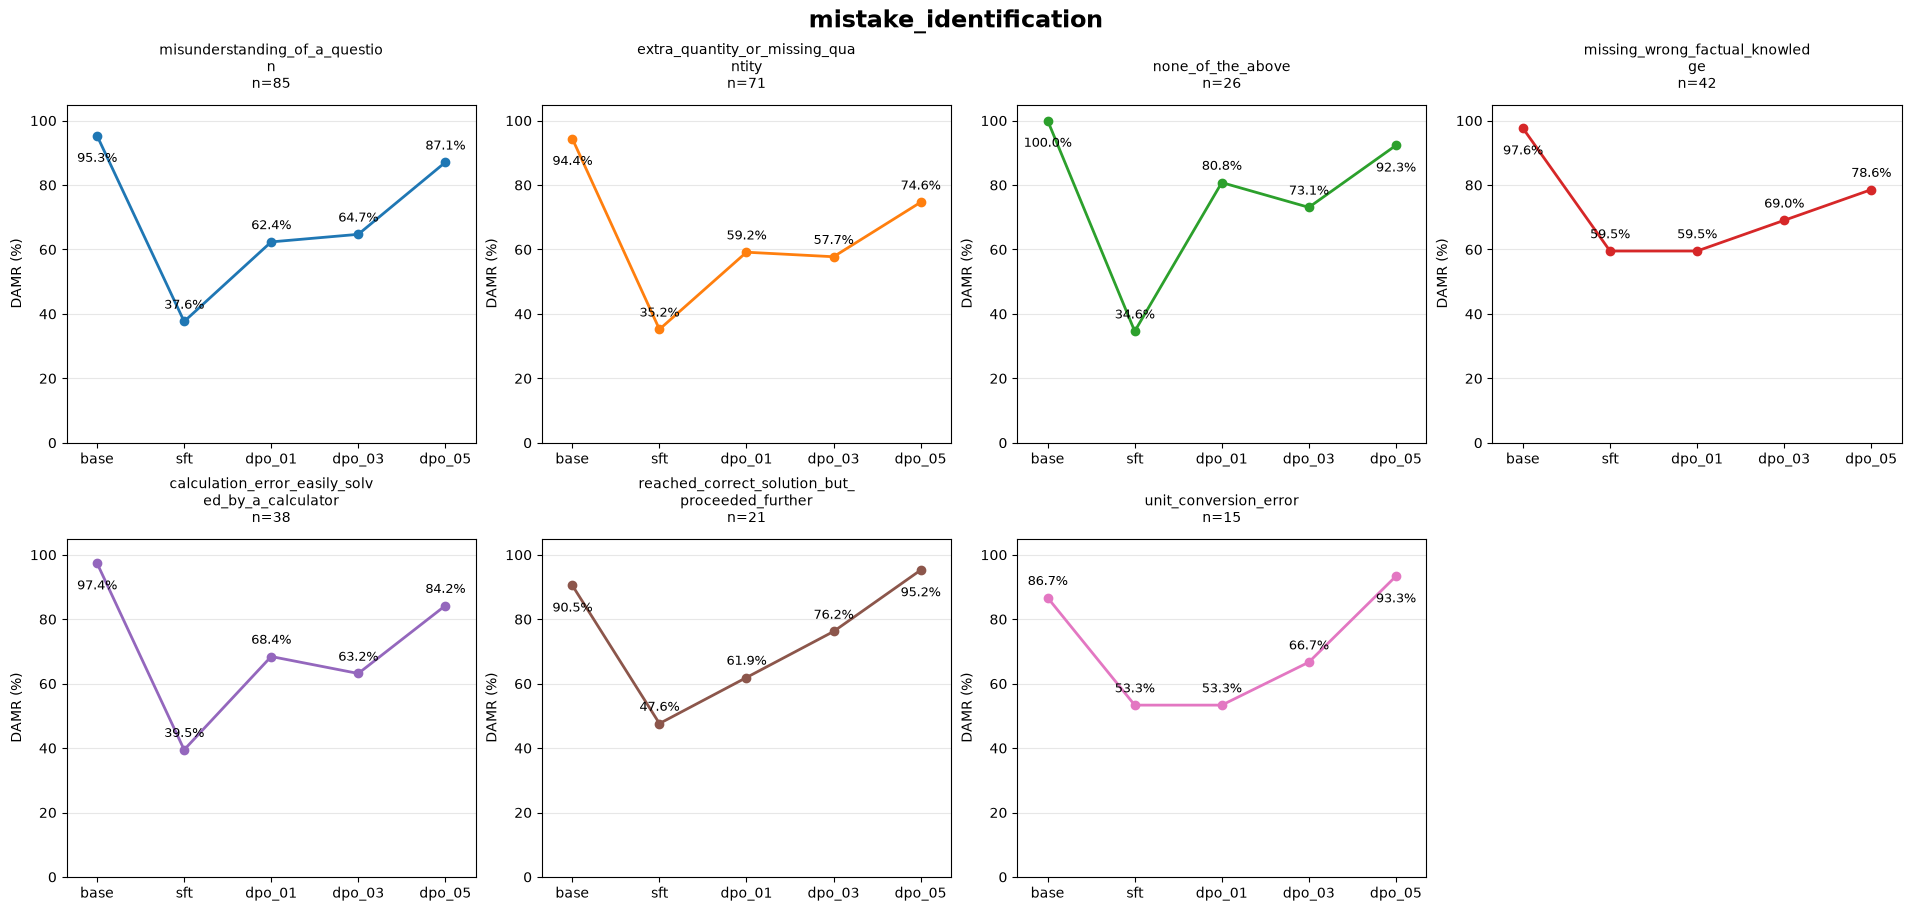

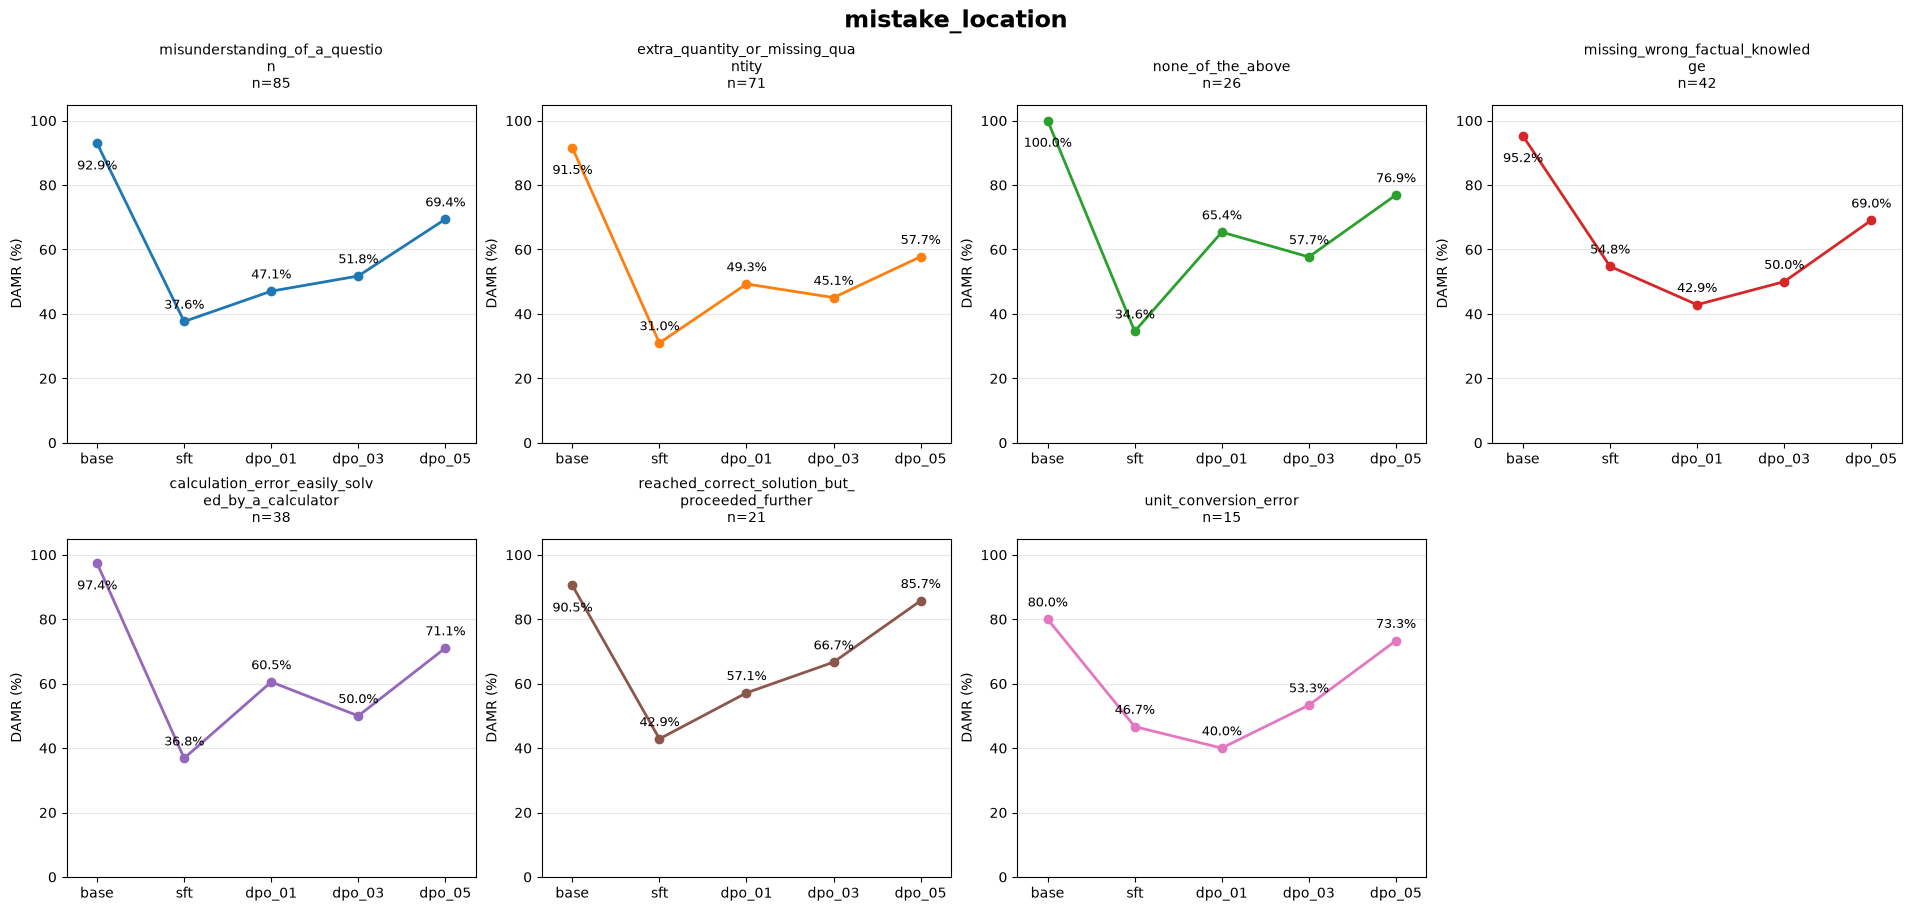

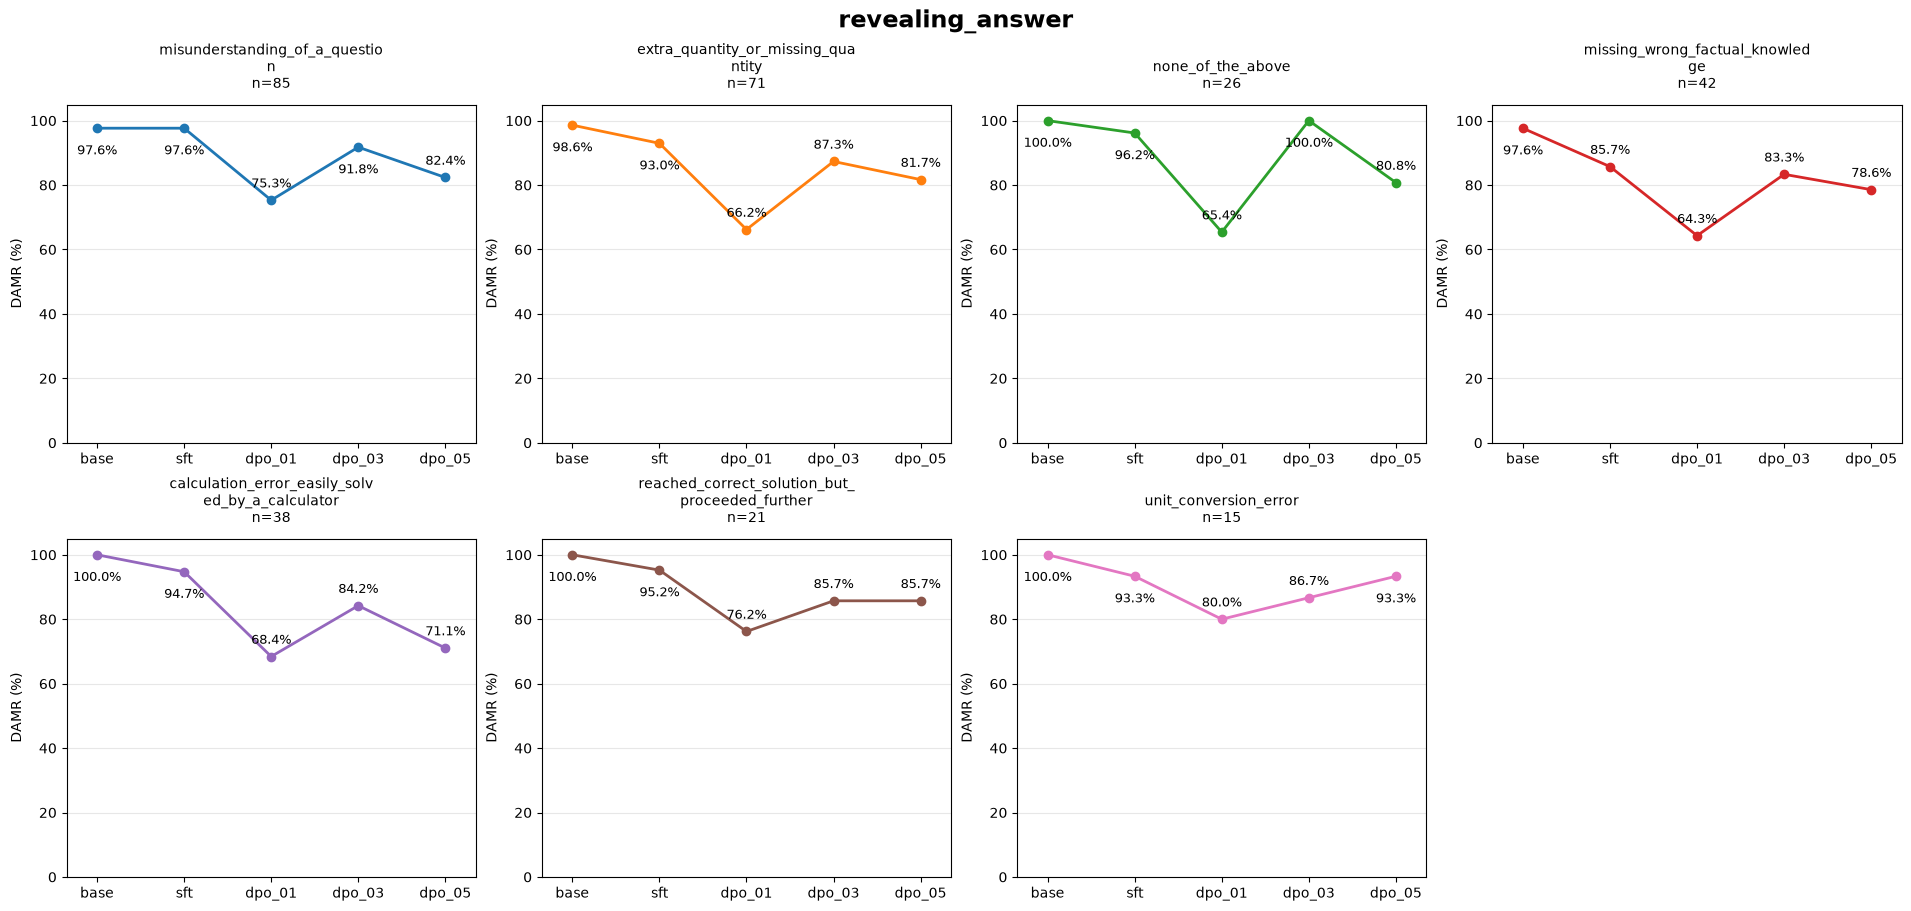

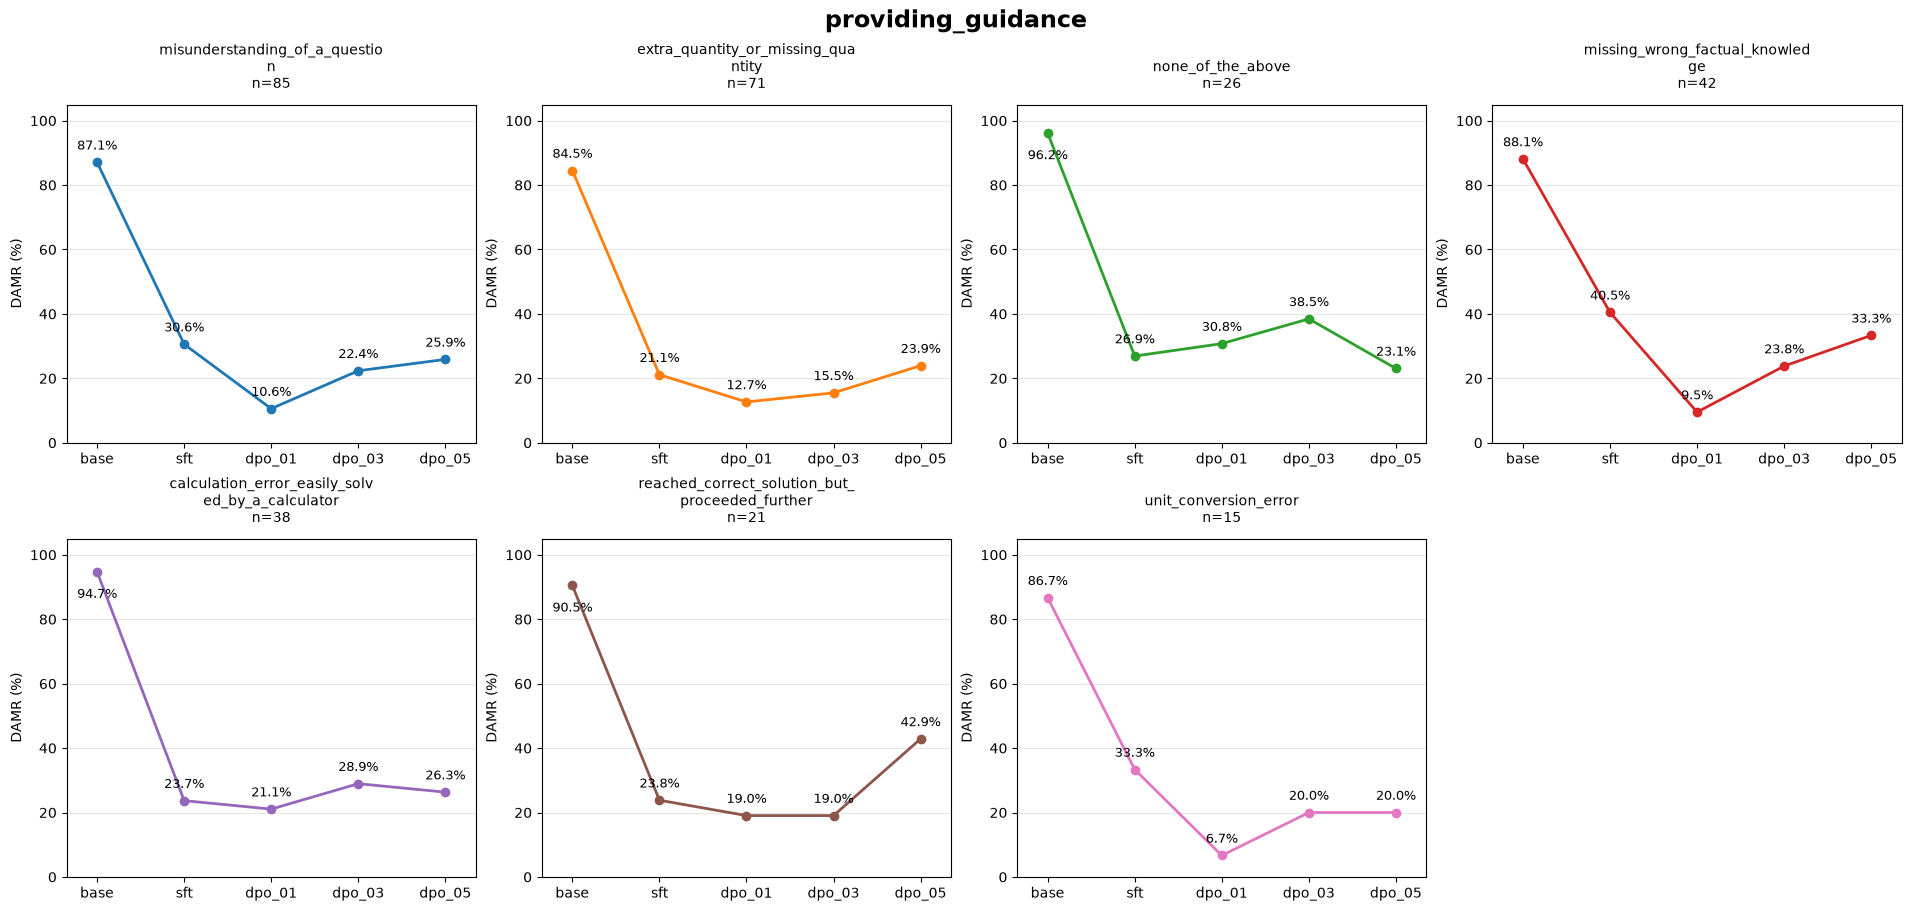

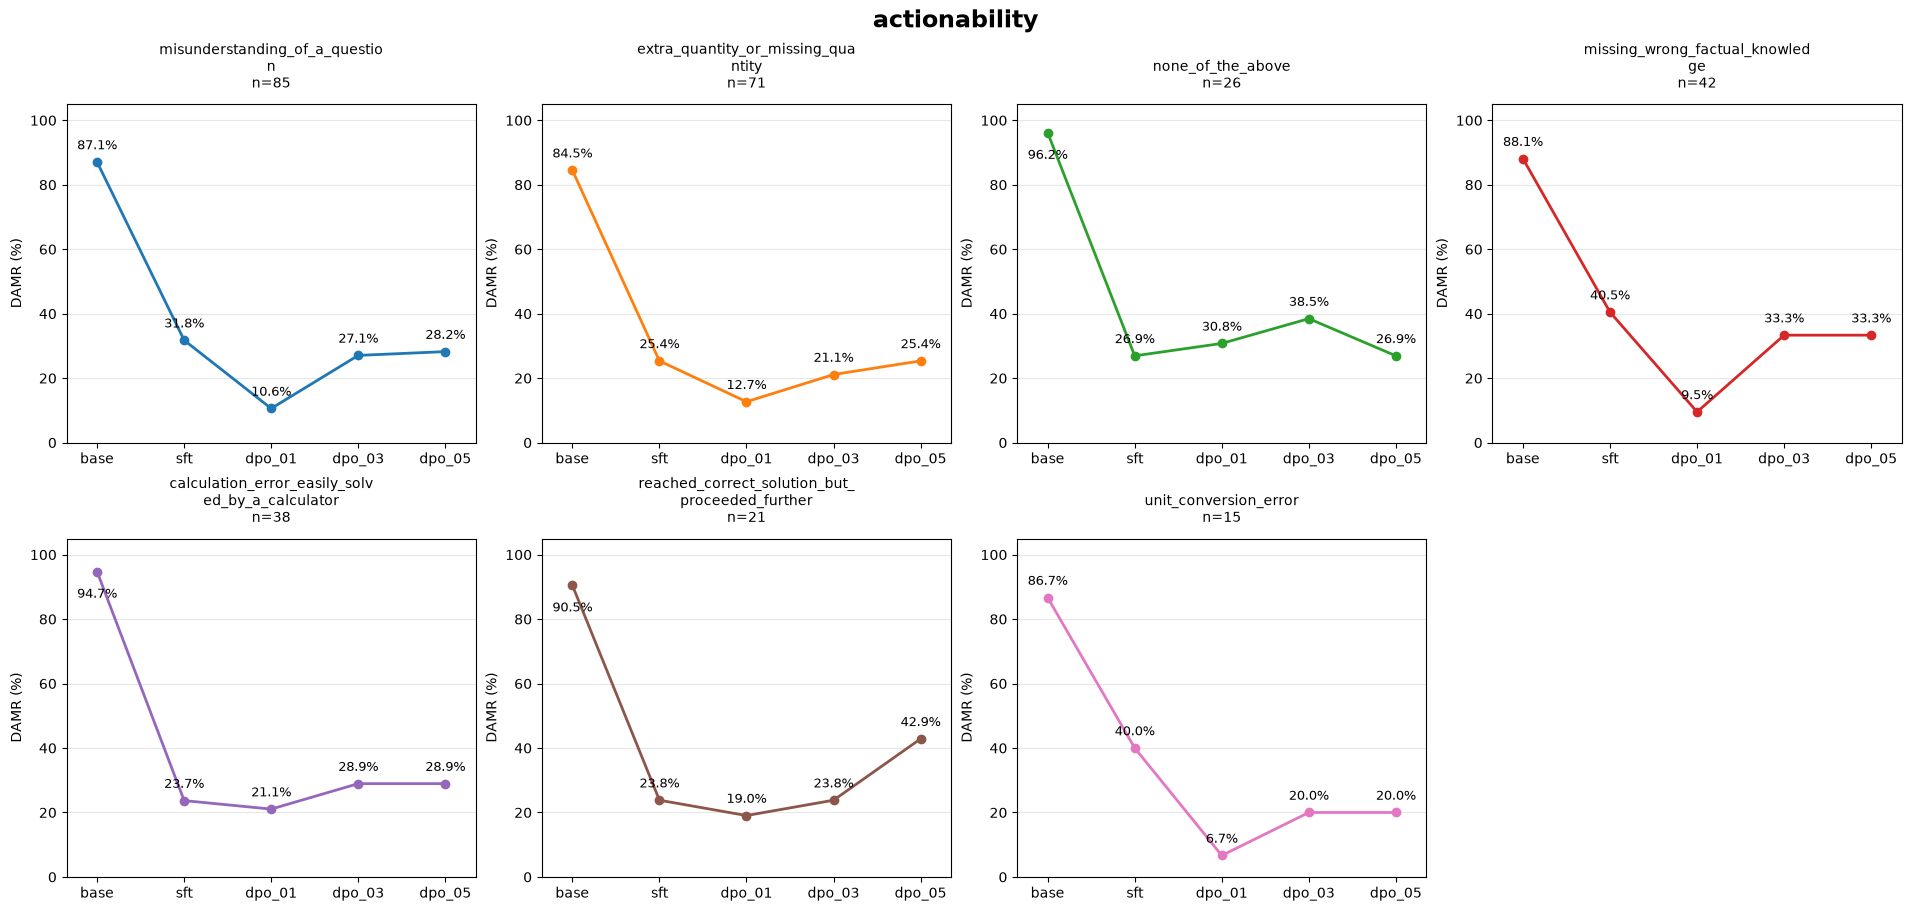

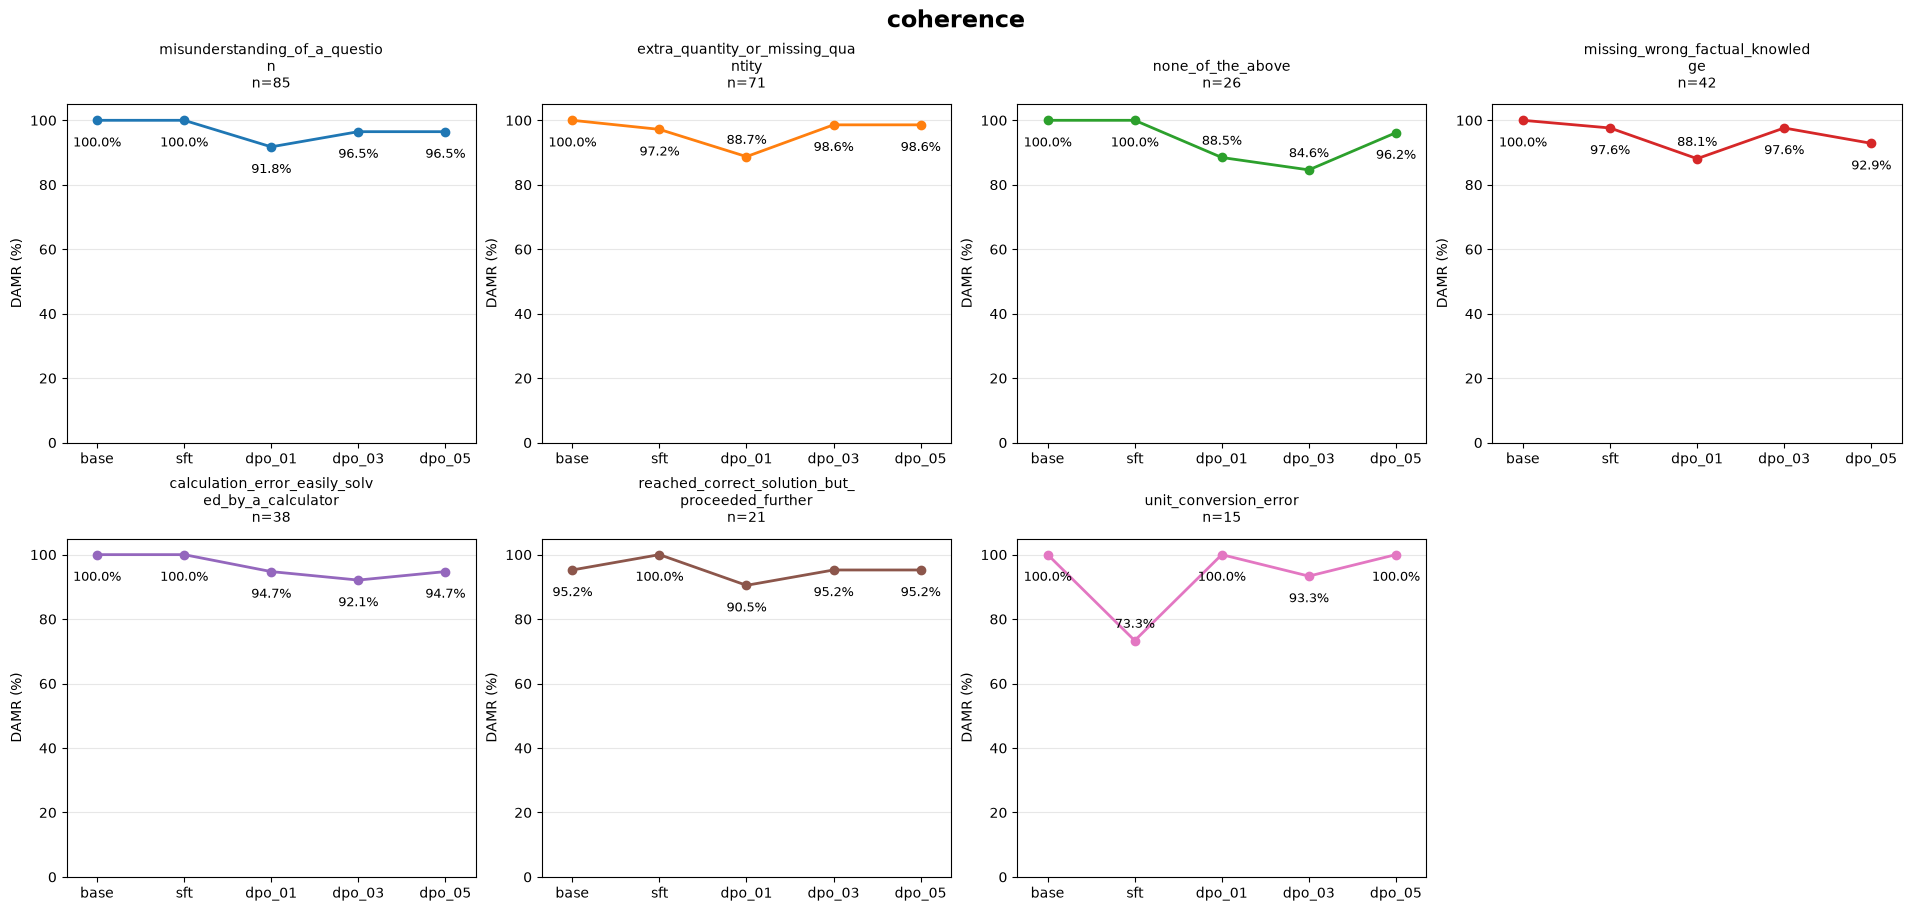

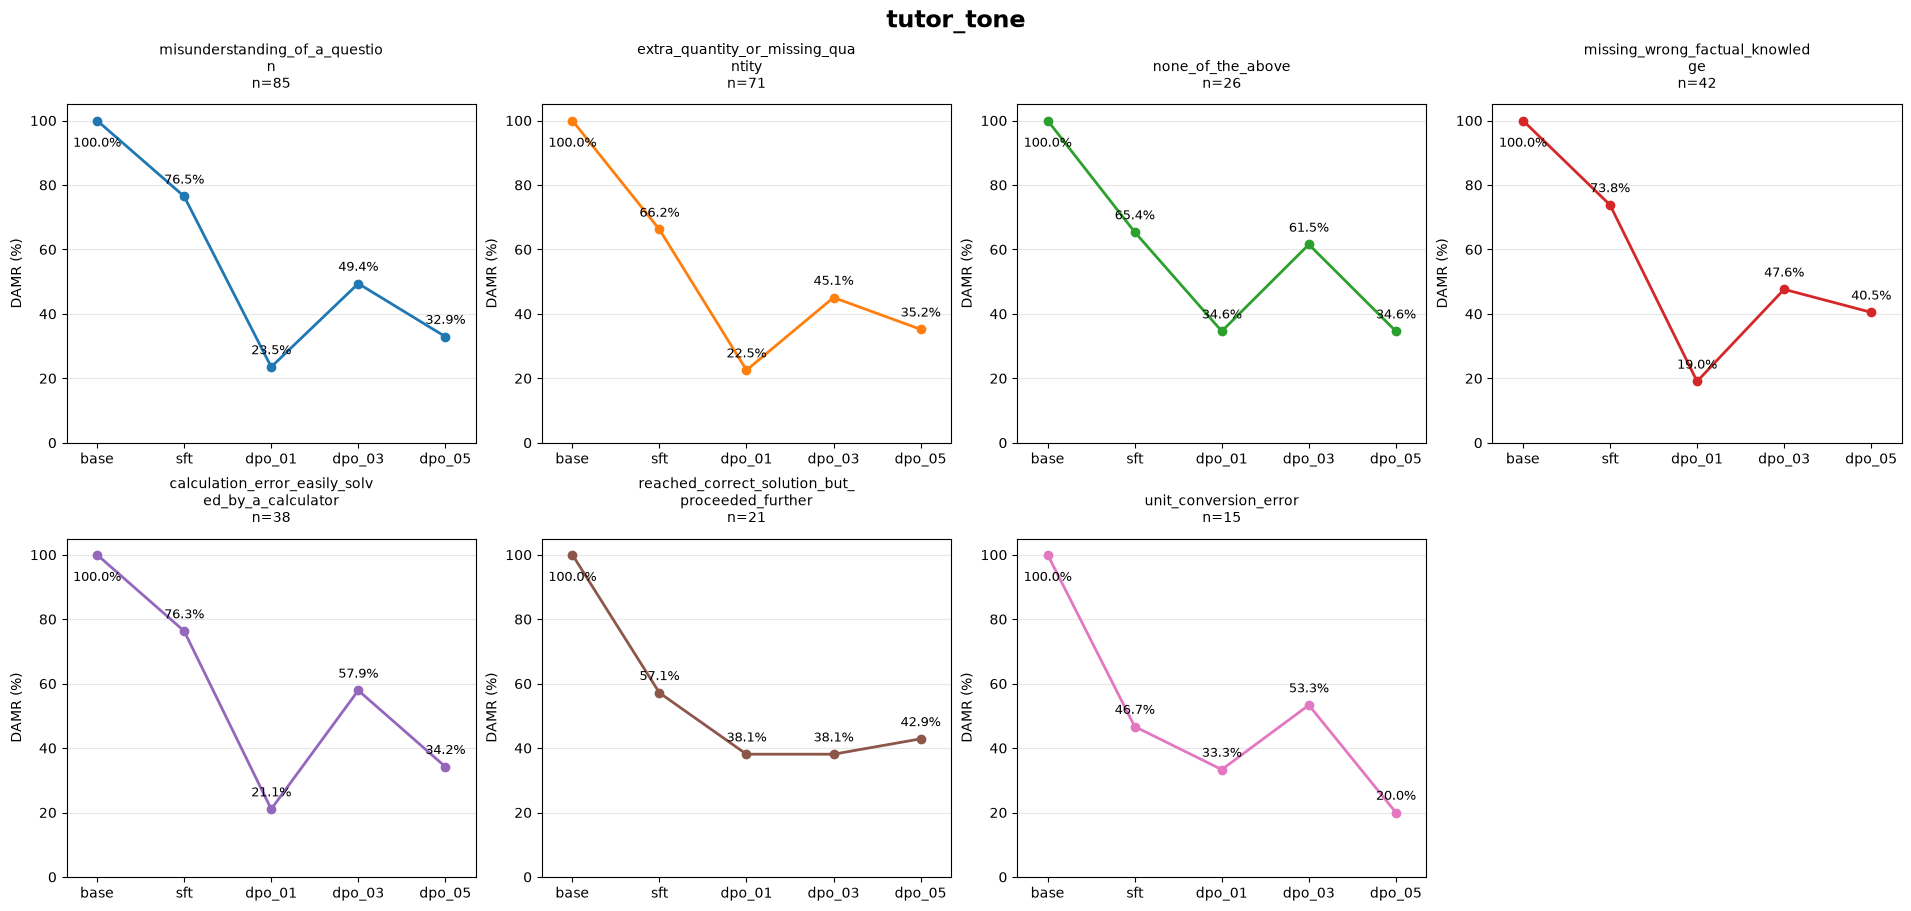

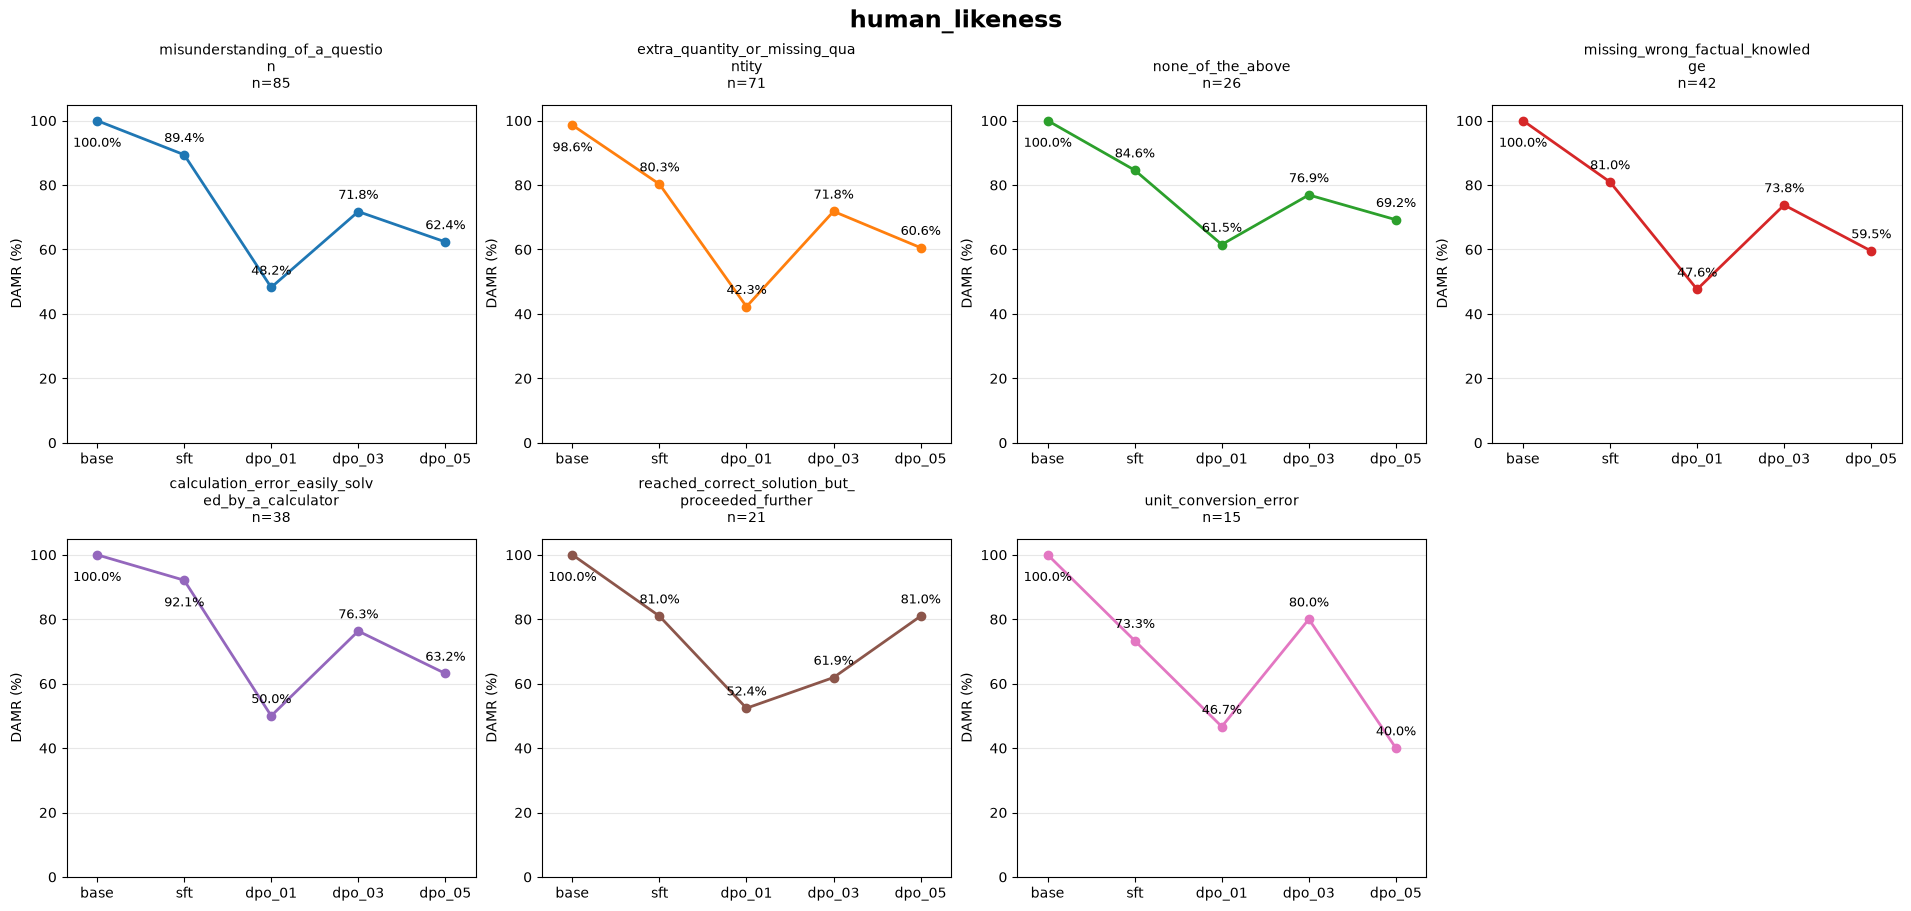

In [4]:
def plot_dimension(dim):
    fig, axes = plt.subplots(2, 4, figsize=(19, 9), sharey=True, layout="constrained")
    fig.suptitle(dim, fontsize=17, fontweight="bold")
    x = np.arange(len(MODEL_ORDER))

    for index, (ax, category) in enumerate(zip(axes.flat, CAT_ORDER)):
        values = damr_by_dimension[dim].loc[category, MODEL_ORDER].to_numpy(dtype=float)
        ax.plot(x, values, marker="o", linewidth=2, color=plt.get_cmap("tab10")(index))

        wrapped = textwrap.fill(category, width=29, break_long_words=True, break_on_hyphens=False)
        ax.set_title(f"{wrapped}\nn={int(category_n.loc[category])}", fontsize=10, pad=12)
        ax.set_xticks(x, MODEL_ORDER)
        ax.set_xlim(-0.35, len(MODEL_ORDER) - 0.65)
        ax.set_ylim(0, 105)
        ax.set_yticks(np.arange(0, 101, 20))
        ax.set_ylabel("DAMR (%)")
        ax.tick_params(axis="y", labelleft=True)
        ax.grid(axis="y", alpha=0.3)

        for position, value in zip(x, values):
            near_top = value >= 90
            ax.annotate(
                f"{value:.1f}%",
                (position, value),
                textcoords="offset points",
                xytext=(0, -12 if near_top else 7),
                ha="center",
                va="top" if near_top else "bottom",
                fontsize=9,
            )

    axes.flat[-1].set_visible(False)
    plt.show()
    plt.close(fig)


for dim in DIMS:
    plot_dimension(dim)

---

## Patterns across models and dimensions

In [5]:
import numpy as np

# Overall (all-category) DAMR trend per dimension: base -> sft -> dpo_01 -> dpo_03 -> dpo_05
trend_rows = []
for dim in DIMS:
    series = model_damr.loc[dim, ALL_MODEL_ORDER]
    diffs = np.diff(series.to_numpy())
    is_monotonic_up = bool(np.all(diffs >= -1e-9))
    is_monotonic_down = bool(np.all(diffs <= 1e-9))
    trend_rows.append({
        "dimension": dim,
        **{model: round(series[model], 1) for model in ALL_MODEL_ORDER},
        "base_to_dpo05_delta": round(series["dpo_05"] - series["base"], 1),
        "monotonic_increase": is_monotonic_up,
        "monotonic_decrease": is_monotonic_down,
    })
trend_df = pd.DataFrame(trend_rows).set_index("dimension")
display(trend_df)

print("\nLargest overall gains (base -> dpo_05):")
print(trend_df["base_to_dpo05_delta"].sort_values(ascending=False).head(3))
print("\nLargest overall drops (base -> dpo_05):")
print(trend_df["base_to_dpo05_delta"].sort_values().head(3))
print("\nMonotonically increasing across base->sft->dpo_01->dpo_03->dpo_05:",
      trend_df.index[trend_df["monotonic_increase"]].tolist())
print("Monotonically decreasing across base->sft->dpo_01->dpo_03->dpo_05:",
      trend_df.index[trend_df["monotonic_decrease"]].tolist())

# Per-dimension: which error_category shows the widest base->dpo_05 swing
print("\nWidest error_category swing per dimension (base -> dpo_05, using damr_by_dimension):")
for dim in DIMS:
    sub = damr_by_dimension[dim]
    if "base" not in sub.columns or "dpo_05" not in sub.columns:
        continue
    swing = (sub["dpo_05"] - sub["base"]).dropna()
    if swing.empty:
        continue
    top_cat = swing.abs().idxmax()
    print(f"  {dim}: {top_cat} ({swing[top_cat]:+.1f} pts)")


,base,sft,dpo_01,dpo_03,dpo_05,base_to_dpo05_delta,monotonic_increase,monotonic_decrease
dimension,,,,,,,,
mistake_identification,95.3,41.6,63.1,65.1,83.9,-11.4,False,False
mistake_location,93.3,38.9,50.7,51.3,68.8,-24.5,False,False
revealing_answer,98.7,94.0,70.1,88.6,80.9,-17.8,False,False
providing_guidance,88.6,28.2,14.4,22.8,27.2,-61.4,False,False
actionability,88.6,29.9,14.4,27.2,28.9,-59.7,False,False
coherence,99.7,97.7,90.9,95.3,96.3,-3.4,False,False
tutor_tone,100.0,69.8,24.8,49.7,34.9,-65.1,False,False
human_likeness,99.7,84.6,48.3,72.8,62.4,-37.2,False,False



Largest overall gains (base -> dpo_05):
dimension
coherence                 -3.4
mistake_identification   -11.4
revealing_answer         -17.8
Name: base_to_dpo05_delta, dtype: float64

Largest overall drops (base -> dpo_05):
dimension
tutor_tone           -65.1
providing_guidance   -61.4
actionability        -59.7
Name: base_to_dpo05_delta, dtype: float64

Monotonically increasing across base->sft->dpo_01->dpo_03->dpo_05: []
Monotonically decreasing across base->sft->dpo_01->dpo_03->dpo_05: []

Widest error_category swing per dimension (base -> dpo_05, using damr_by_dimension):
  mistake_identification: extra_quantity_or_missing_quantity (-19.7 pts)
  mistake_location: extra_quantity_or_missing_quantity (-33.8 pts)
  revealing_answer: calculation_error_easily_solved_by_a_calculator (-28.9 pts)
  providing_guidance: none_of_the_above (-73.1 pts)
  actionability: none_of_the_above (-69.2 pts)
  coherence: missing_wrong_factual_knowledge (-7.1 pts)
  tutor_tone: unit_conversion_error (-

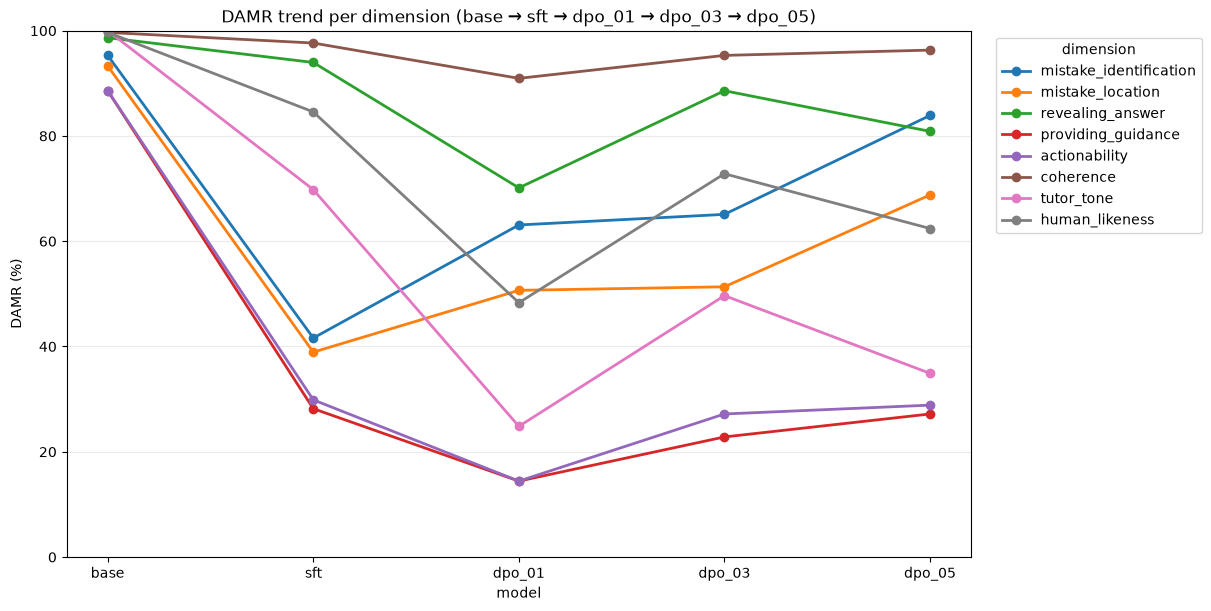

In [6]:
# Visualize the patterns described above: per-dimension trend lines.

fig, ax = plt.subplots(figsize=(12, 6), layout="constrained")
for dim in DIMS:
    ax.plot(ALL_MODEL_ORDER, model_damr.loc[dim, ALL_MODEL_ORDER], marker="o", linewidth=2, label=dim)
ax.set_ylim(0, 100)
ax.set_ylabel("DAMR (%)")
ax.set_xlabel("model")
ax.set_title("DAMR trend per dimension (base → sft → dpo_01 → dpo_03 → dpo_05)")
ax.legend(title="dimension", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.grid(axis="y", alpha=0.25)
plt.show()
plt.close(fig)